In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Notebook 4: Afluencia de clientes en ventas Local

En este notebook se estima cuántas personas llegaron a cada mesa usando los platillos principales de la venta. El campo `Personas` del POS no se usa porque no se llena de forma consistente.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

In [3]:
df = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
df_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

df = pd.concat([df, df_26], ignore_index=True)

df = df[(df['Estado'] == 'Cerrada') & (df['Total'] > 0)].copy()
df['Creación'] = pd.to_datetime(df['Creación'])
df['Fecha'] = df['Creación'].dt.normalize()
df['Año'] = df['Creación'].dt.year
df['Mes'] = df['Creación'].dt.month
df['Dia'] = df['Creación'].dt.day
df['Dia_semana'] = df['Creación'].dt.dayofweek
df['Hora'] = df['Creación'].dt.hour

ventas = df[df['Tipo de Venta'] == 'Local'].copy()

## Alcance

Este análisis solo usa ventas tipo `Local`, porque ahí sí tiene sentido estimar cuántas personas estaban comiendo en la misma mesa. Las ventas de `Mostrador` se excluyen: una orden para llevar no permite saber si la comida era para una persona, una familia o varias personas en lugares distintos.

In [4]:
ad = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Adiciones')
ad_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Adiciones')

ad = pd.concat([ad, ad_26], ignore_index=True)
ad = ad[ad['Cancelada'] != 'Sí'].copy()
ad['Cantidad'] = pd.to_numeric(ad['Cantidad'], errors='coerce').fillna(0)

principales = [
    'Milanesas Y Pollo', 'Hamburguesas', 'Chilaquiles', 'Huevos Al Gusto',
    'Cortes', 'Pescados Y Mariscos', 'Parrillada', 'Omelette',
    'Enchiladas', 'Menú Infantil', 'Chuleta Suiza', 'POZOLE',
    'Plato Fuerte', 'Tacos', 'Desayuno'
]

platos = ad[ad['Categoría'].isin(principales)].copy()

comensales = platos.groupby('Id. Venta', as_index=False)['Cantidad'].sum()
comensales = comensales.rename(columns={'Cantidad': 'comensales_estimados'})

familias = ad[ad['Categoría'] == 'Menú Infantil'][['Id. Venta']].drop_duplicates()
familias['familia'] = True

ventas = ventas.merge(comensales, left_on='Id', right_on='Id. Venta', how='left')
ventas = ventas.merge(familias, left_on='Id', right_on='Id. Venta', how='left')

ventas['comensales_estimados'] = ventas['comensales_estimados'].fillna(0)
ventas['familia'] = ventas['familia'].fillna(False)

ventas['tipo_grupo'] = pd.NA
ventas.loc[ventas['comensales_estimados'] == 1, 'tipo_grupo'] = 'solo'
ventas.loc[ventas['comensales_estimados'] == 2, 'tipo_grupo'] = 'pareja'
ventas.loc[ventas['comensales_estimados'] >= 3, 'tipo_grupo'] = 'grupo'
ventas.loc[
    (ventas['familia']) & (ventas['comensales_estimados'] > 0),
    'tipo_grupo'
] = 'familia'

sin_plato = (ventas['comensales_estimados'] == 0).sum()

ventas_grupo = ventas[ventas['comensales_estimados'] > 0].copy()
ventas_grupo['gasto_persona'] = (
    ventas_grupo['Total'] / ventas_grupo['comensales_estimados']
)

## Cómo se interpreta esta estimación

Esto no es un conteo real de personas. Se infiere a partir de los platillos principales que se pidieron: dos personas pueden compartir un platillo grande, y una persona sola puede pedir dos platillos. Es una aproximación razonable para ver tendencias de afluencia, pero no un dato exacto por venta.

In [5]:
display(Markdown(
    f"""
## Ventas sin platillo principal

Se excluyeron **{sin_plato:,} ventas Local** de la clasificación porque no tenían ningún platillo principal registrado. Principalmente son cuentas de bebidas, entradas, extras o consumos donde el método no permite estimar cuántas personas comieron.
"""
))


## Ventas sin platillo principal

Se excluyeron **719 ventas Local** de la clasificación porque no tenían ningún platillo principal registrado. Principalmente son cuentas de bebidas, entradas, extras o consumos donde el método no permite estimar cuántas personas comieron.


## 1. Mezcla de ventas Local: solo, pareja, grupo y familia

Los porcentajes se calculan sobre las ventas Local que sí tuvieron al menos un platillo principal.

In [6]:
orden = ['solo', 'pareja', 'grupo', 'familia']

dist = ventas_grupo.groupby(['Año', 'tipo_grupo']).size().unstack(fill_value=0)
dist = dist.reindex(columns=orden, fill_value=0)

dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100

display(dist)
display(dist_pct.round(1))

tipo_grupo,solo,pareja,grupo,familia
Año,,,,
2025,1478,1216,770,212
2026,1053,899,487,120


tipo_grupo,solo,pareja,grupo,familia
Año,,,,
2025,40.2,33.1,20.9,5.8
2026,41.1,35.1,19.0,4.7


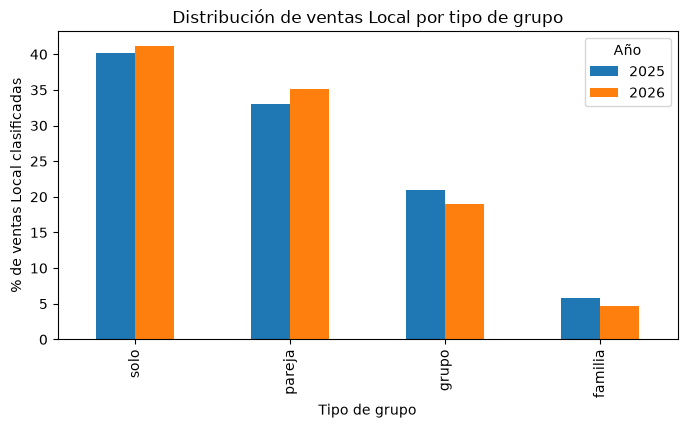

In [7]:
ax = dist_pct.T.plot(kind='bar', figsize=(8, 4))
ax.set_title('Distribución de ventas Local por tipo de grupo')
ax.set_xlabel('Tipo de grupo')
ax.set_ylabel('% de ventas Local clasificadas')
plt.show()

## 2. Ticket promedio y gasto estimado por persona

El gasto por persona se calcula en cada venta como `Total / comensales_estimados` y después se promedia dentro de cada tipo de grupo.

In [8]:
ticket = ventas_grupo.groupby(['Año', 'tipo_grupo']).agg(
    Tickets=('Id', 'count'),
    Ticket_promedio=('Total', 'mean'),
    Gasto_persona_promedio=('gasto_persona', 'mean'),
    Comensales_promedio=('comensales_estimados', 'mean')
)

ticket = ticket.reindex(
    pd.MultiIndex.from_product(
        [sorted(ventas_grupo['Año'].unique()), orden],
        names=['Año', 'tipo_grupo']
    )
)

display(ticket.round(2))

Tickets  Ticket_promedio  Gasto_persona_promedio  \
Año  tipo_grupo                                                     
2025 solo           1478           150.97                  150.97   
     pareja         1216           264.38                  132.19   
     grupo           770           459.94                  119.94   
     familia         212           392.30                  129.85   
2026 solo           1053           178.85                  178.85   
     pareja          899           309.99                  154.99   
     grupo           487           640.12                  146.53   
     familia         120           525.90                  146.93   

                 Comensales_promedio  
Año  tipo_grupo                       
2025 solo                       1.00  
     pareja                     2.00  
     grupo                      3.92  
     familia                    3.19  
2026 solo                       1.00  
     pareja                     2.00  
     grupo                      4.27  
     familia                    3.58

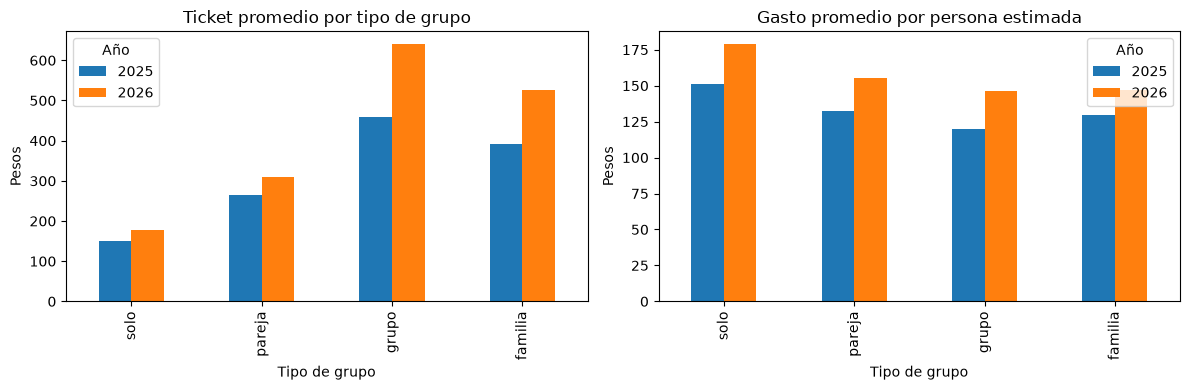

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ticket['Ticket_promedio'].unstack('Año').reindex(orden).plot(kind='bar', ax=ax[0])
ax[0].set_title('Ticket promedio por tipo de grupo')
ax[0].set_xlabel('Tipo de grupo')
ax[0].set_ylabel('Pesos')

ticket['Gasto_persona_promedio'].unstack('Año').reindex(orden).plot(kind='bar', ax=ax[1])
ax[1].set_title('Gasto promedio por persona estimada')
ax[1].set_xlabel('Tipo de grupo')
ax[1].set_ylabel('Pesos')

plt.tight_layout()
plt.show()

## 3. Horas en que predomina cada tipo de grupo

In [10]:
por_hora = ventas_grupo.groupby(['Año', 'Hora', 'tipo_grupo']).size().unstack(fill_value=0)
por_hora = por_hora.reindex(columns=orden, fill_value=0)

por_hora_pct = por_hora.div(por_hora.sum(axis=1), axis=0) * 100
por_hora_pct['Predomina'] = por_hora_pct[orden].idxmax(axis=1)

display(por_hora_pct.round(1))

tipo_grupo  solo  pareja  grupo  familia Predomina
Año  Hora                                         
2025 7      40.0    60.0    0.0      0.0    pareja
     8      50.4    27.2   18.5      3.9      solo
     9      44.5    29.6   20.5      5.4      solo
     10     35.5    35.8   22.8      5.9    pareja
     11     44.4    34.2   15.6      5.7      solo
     12     40.8    33.3   18.4      7.5      solo
     13     31.5    40.7   20.7      7.1    pareja
     14     32.6    35.6   26.3      5.4    pareja
     15     42.7    34.1   19.9      3.3      solo
     16     44.0    28.3   20.8      6.8      solo
     17     42.7    30.1   22.0      5.2      solo
     18     36.4    35.1   20.5      7.9      solo
     19     39.5    34.9   22.1      3.5      solo
     20     33.3    25.9   33.3      7.4      solo
     21     15.4    30.8   30.8     23.1    pareja
     22      0.0     0.0    0.0    100.0   familia
     23      0.0    50.0   50.0      0.0    pareja
2026 7      42.3    46.2   11.5      0.0    pareja
     8      40.3    37.9   18.5      3.3      solo
     9      42.7    33.7   19.8      3.7      solo
     10     42.4    36.6   16.9      4.1      solo
     11     43.2    31.7   19.1      6.0      solo
     12     41.0    36.4   18.5      4.0      solo
     13     39.1    39.1   17.3      4.6      solo
     14     36.7    29.5   26.6      7.2      solo
     15     39.2    40.9   16.9      3.0    pareja
     16     42.6    35.1   18.1      4.3      solo
     17     38.7    33.1   22.7      5.5      solo
     18     42.9    29.9   21.8      5.4      solo
     19     48.2    31.9   12.1      7.8      solo
     20     34.0    40.0   22.0      4.0    pareja
     21      0.0     0.0    0.0    100.0   familia
     22      0.0     0.0  100.0      0.0     grupo

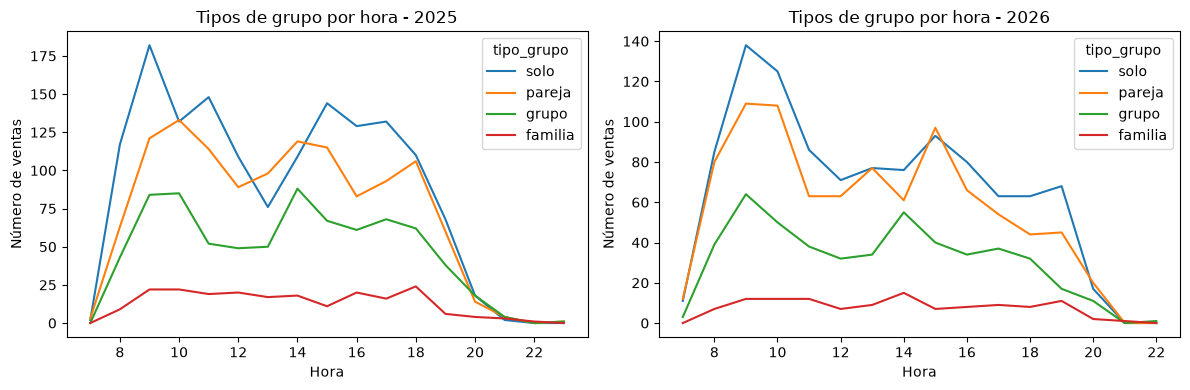

In [11]:
años = sorted(ventas_grupo['Año'].unique())

fig, ax = plt.subplots(1, len(años), figsize=(12, 4))

for eje, año in zip(ax, años):
    por_hora.loc[año, orden].plot(ax=eje)
    eje.set_title(f'Tipos de grupo por hora - {año}')
    eje.set_xlabel('Hora')
    eje.set_ylabel('Número de ventas')

plt.tight_layout()
plt.show()

## 4. Días en que predomina cada tipo de grupo

In [12]:
dias = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

orden_dias = list(dias.values())

ventas_grupo['Dia_nombre'] = ventas_grupo['Dia_semana'].map(dias)
ventas_grupo['Dia_nombre'] = pd.Categorical(
    ventas_grupo['Dia_nombre'],
    categories=orden_dias,
    ordered=True
)

por_dia = ventas_grupo.groupby(['Año', 'Dia_nombre', 'tipo_grupo']).size().unstack(fill_value=0)
por_dia = por_dia.reindex(columns=orden, fill_value=0)

por_dia_pct = por_dia.div(por_dia.sum(axis=1), axis=0) * 100
por_dia_pct['Predomina'] = por_dia_pct[orden].idxmax(axis=1)

display(por_dia_pct.round(1))

tipo_grupo       solo  pareja  grupo  familia Predomina
Año  Dia_nombre                                        
2025 Lunes       37.5    34.7   22.4      5.4      solo
     Martes      43.9    32.4   19.5      4.3      solo
     Miércoles   45.1    30.6   20.3      4.0      solo
     Jueves      46.0    31.2   17.2      5.7      solo
     Viernes     39.5    33.9   21.2      5.4      solo
     Sábado      35.8    33.4   23.8      7.1      solo
     Domingo     36.0    34.7   21.4      7.9      solo
2026 Lunes       46.1    34.1   15.8      4.1      solo
     Martes      41.8    39.4   14.6      4.2      solo
     Miércoles   40.1    36.4   20.7      2.8      solo
     Jueves      44.9    34.1   16.6      4.4      solo
     Viernes     45.4    31.8   17.5      5.3      solo
     Sábado      39.3    35.0   20.5      5.1      solo
     Domingo     32.4    35.5   25.8      6.4    pareja

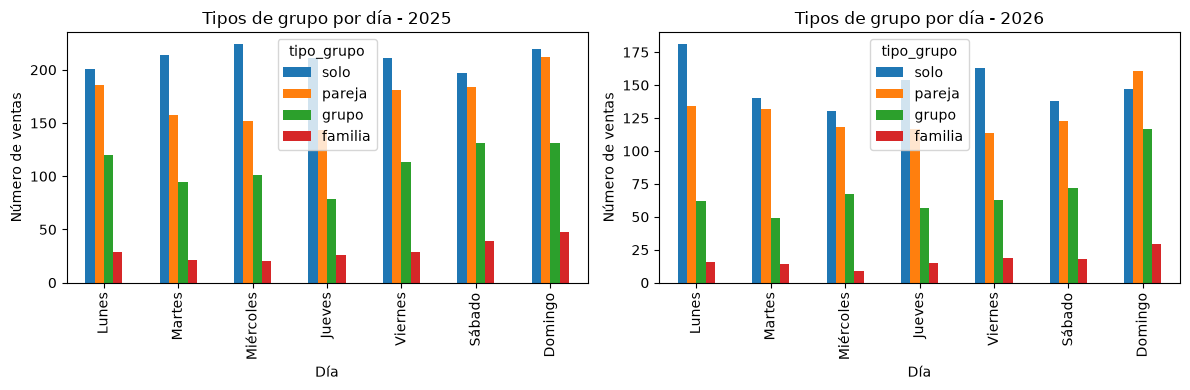

In [13]:
fig, ax = plt.subplots(1, len(años), figsize=(12, 4))

for eje, año in zip(ax, años):
    por_dia.loc[año, orden].plot(kind='bar', ax=eje)
    eje.set_title(f'Tipos de grupo por día - {año}')
    eje.set_xlabel('Día')
    eje.set_ylabel('Número de ventas')

plt.tight_layout()
plt.show()

In [14]:
actual = 2026

cambio = dist_pct.loc[actual] - dist_pct.loc[2025]
mayor_subida = cambio.idxmax()
mayor_bajada = cambio.idxmin()

tipo_principal = dist_pct.loc[actual].idxmax()
hora_principal = por_hora.loc[actual, tipo_principal].idxmax()
dia_principal = por_dia.loc[actual, tipo_principal].idxmax()

hora_familia = por_hora.loc[actual, 'familia'].idxmax()
dia_familia = por_dia.loc[actual, 'familia'].idxmax()

hora_grupo = por_hora.loc[actual, 'grupo'].idxmax()
dia_grupo = por_dia.loc[actual, 'grupo'].idxmax()

familia_domingo = por_dia_pct.loc[(actual, 'Domingo'), 'familia']
familia_total = dist_pct.loc[actual, 'familia']

fin_2026 = ventas_grupo[ventas_grupo['Año'] == actual]['Fecha'].max().strftime('%d-%m-%Y')

In [15]:
display(Markdown(
    f"""
## Lectura final

- En {actual}, el tipo de grupo más frecuente fue **{tipo_principal}**, con {dist_pct.loc[actual, tipo_principal]:.1f}% de las ventas Local clasificadas. Por día, se concentró más el **{dia_principal}**; por hora, a las **{hora_principal}:00 h** (no necesariamente el mismo cruce día-hora).
- Frente a 2025, el cambio más grande en la mezcla fue **{mayor_subida}**, con {cambio[mayor_subida]:+.1f} puntos porcentuales. El tipo que más bajó fue **{mayor_bajada}**, con {cambio[mayor_bajada]:+.1f} puntos.
- Las familias representaron {familia_total:.1f}% de las ventas Local clasificadas en 2026 y {familia_domingo:.1f}% de las ventas Local del domingo. Esto sirve para revisar si el nuevo local, frente al parque y junto a la iglesia, está atrayendo más consumo familiar en ciertos horarios.
- Los resultados de 2026 llegan hasta el **{fin_2026}**. Además, desde enero cambiaron al mismo tiempo la ubicación, el tamaño del local y los precios, mientras que desde diciembre de 2025 ya no está el mercado cercano. Por eso la comparación muestra cambios reales en la mezcla de ventas, pero no permite atribuirlos a una sola causa.

## Ideas para probar

1. Preparar una opción rápida para **{tipo_principal}** los **{dia_principal}** alrededor de las **{hora_principal}:00 h**, con un platillo principal y bebida en un solo paquete.
2. Probar un paquete familiar los **{dia_familia}** a las **{hora_familia}:00 h**, incluyendo al menos una opción de `Menú Infantil`, ya que esa categoría permite identificar consumo familiar sin usar datos personales.
3. Ofrecer una promoción de mesa compartida o reservación sencilla para grupos los **{dia_grupo}** alrededor de las **{hora_grupo}:00 h**, aprovechando que el local nuevo tiene más espacio para reuniones.
"""
))


## Lectura final

- En 2026, el tipo de grupo más frecuente fue **solo**, con 41.1% de las ventas Local clasificadas. Por día, se concentró más el **Lunes**; por hora, a las **9:00 h** (no necesariamente el mismo cruce día-hora).
- Frente a 2025, el cambio más grande en la mezcla fue **pareja**, con +2.1 puntos porcentuales. El tipo que más bajó fue **grupo**, con -1.9 puntos.
- Las familias representaron 4.7% de las ventas Local clasificadas en 2026 y 6.4% de las ventas Local del domingo. Esto sirve para revisar si el nuevo local, frente al parque y junto a la iglesia, está atrayendo más consumo familiar en ciertos horarios.
- Los resultados de 2026 llegan hasta el **06-10-2026**. Además, desde enero cambiaron al mismo tiempo la ubicación, el tamaño del local y los precios, mientras que desde diciembre de 2025 ya no está el mercado cercano. Por eso la comparación muestra cambios reales en la mezcla de ventas, pero no permite atribuirlos a una sola causa.

## Ideas para probar

1. Preparar una opción rápida para **solo** los **Lunes** alrededor de las **9:00 h**, con un platillo principal y bebida en un solo paquete.
2. Probar un paquete familiar los **Domingo** a las **14:00 h**, incluyendo al menos una opción de `Menú Infantil`, ya que esa categoría permite identificar consumo familiar sin usar datos personales.
3. Ofrecer una promoción de mesa compartida o reservación sencilla para grupos los **Domingo** alrededor de las **9:00 h**, aprovechando que el local nuevo tiene más espacio para reuniones.
